# Supervised Machine Learning 

**Datasets:**
- **Regression:** 2015 US Domestic Flights dataset (predicting `ARRIVAL_DELAY`)
- **Classification:** Breast Cancer Wisconsin (Diagnostic) dataset (predicting benign vs malignant)

This notebook is organized in two parts:

1. **Part 1 — Concepts.** 
2. **Part 2 — Case Study.**

In [2]:
# Core imports used throughout the notebook
import numpy as np                          
import pandas as pd                          
import matplotlib.pyplot as plt            
import seaborn as sns                       
import warnings
warnings.filterwarnings('ignore')            # silence harmless warning spam 

sns.set_style('whitegrid')                   
# by using rcParams we write these settings once and every graph automatically uses it
plt.rcParams['figure.figsize'] = (9, 5)     
plt.rcParams['axes.titlesize'] = 13         
plt.rcParams['axes.titleweight'] = 'bold'    

RANDOM_STATE = 42                            # a fixed seed number, reused everywhere below
np.random.seed(RANDOM_STATE)                 # seed numpy's random generator so random results are reproducible


# Part 1 — Concepts

## 1. Supervised Machine Learning

In supervised learning, a model learns from a labelled dataset — every input comes with a known, correct output. During training the model compares its own predictions against the true labels and adjusts itself to close the gap. Once it performs well on data it has already seen, it is tested on fresh, unseen data to check how well it generalizes, and can then be used to make predictions on brand-new inputs.

Two broad families:

•	Regression — the target y is a continuous number (e.g. house price, temperature, flight delay in minutes).

•	Classification — the target y is a discrete category (e.g. spam/not-spam, benign/malignant, delayed/on-time).
Example: Predicting a flight's arrival delay in minutes is regression. Predicting whether a tumor is malignant or benign is classification. Both are supervised because we have historical, labeled examples to learn from.

Strengths and limitations: Supervised learning is easy to reason about and tends to be highly accurate when enough labelled data is available. 

Its main drawback is that it depends on large amounts of labelled data, which is often expensive and slow to collect, and a model trained on an unbalanced dataset can end up biased toward the majority class.


## 2. Regression vs Classification

| | Regression | Classification |
|---|---|---|
| Output type | Continuous number | Discrete class/category |
| Example question | "How many minutes will this flight be delayed?" | "Is this flight going to be delayed (Yes/No)?" |
| Typical algorithms | Linear Regression, Ridge, Lasso, Decision Tree Regressor, Random Forest Regressor | Logistic Regression, KNN, Naive Bayes, Decision Tree, Random Forest, SVM |
| Typical metrics | MAE, MSE, RMSE, R² | Accuracy, Precision, Recall, F1, ROC-AUC |

Some algorithms (Decision Trees, Random Forests, SVM, KNN) have both a regressor and a classifier version — the underlying idea (splitting data / finding a boundary /finding neighbors ) is similar, but the output and loss function differ.


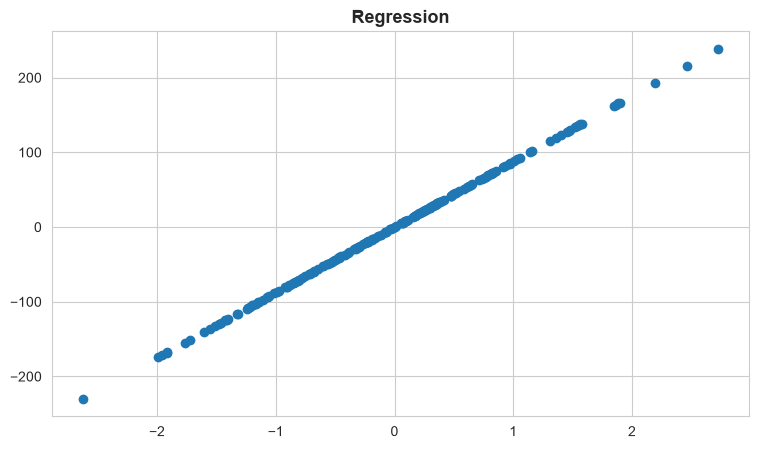

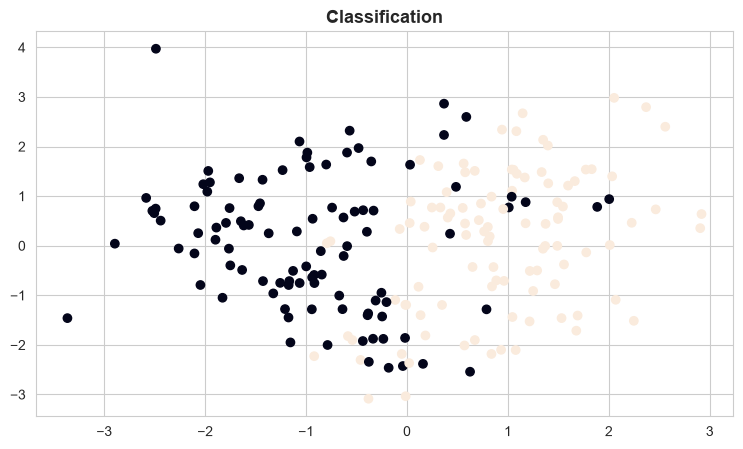

In [3]:
#example using data generators
from sklearn.datasets import make_regression, make_classification   # sklearn helpers that fabricate toy datasets

# 200 datapoints each datapoint has one col
# Xr = input features yr = target value 
Xr, yr = make_regression(n_samples=200, n_features=1, random_state=42)  # generate a fake regression dataset 
plt.scatter(Xr, yr)                      
plt.title("Regression")
plt.show()# render the figure

# 200 rows, 4 input features
Xc, yc = make_classification(n_samples=200, n_features=4, random_state=42)  # generate a fake classification dataset (yc = 0/1 class labels)
plt.scatter(Xc[:,0], Xc[:,1], c=yc)          # take the first feature for every row and then the second feature as x-axis/y-axis c=yc colors points by class
plt.title("Classification")
plt.show()


## 3. Bias-Variance Tradeoff

- **Bias** Error caused by overly simple assumptions in the model, which may lead to underfitting. (e.g. fitting a straight line to curved data).
- **Variance** is the error from being overly sensitive to the training data's noise. High-variance models overfit — they memorize noise instead of the underlying pattern.

Total expected error ≈ **Bias² + Variance + Irreducible noise**. There's a tradeoff: as model complexity increases, bias tends to fall but variance tends to rise. The goal is to balance bias and variance so the model captures patterns while still generalizing well to new data.

**Example:** A single Decision Tree grown very deep has low bias (fits training data almost perfectly) but high variance (small changes in data drastically change the tree). A Random Forest reduces variance by averaging many such trees.


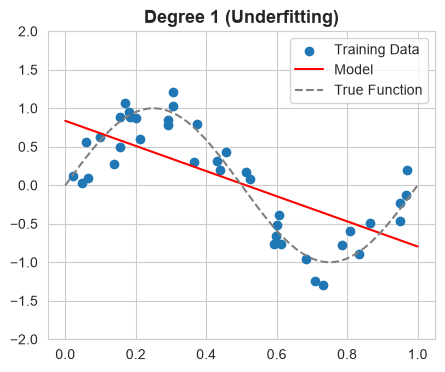

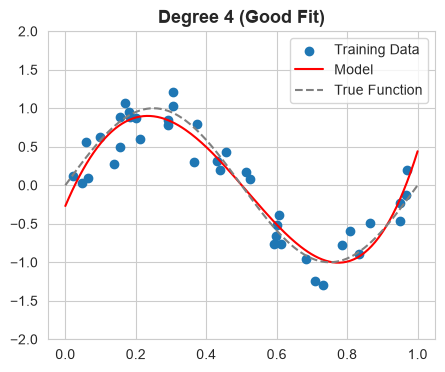

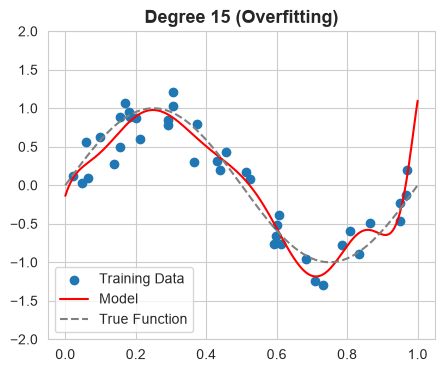

In [4]:
from sklearn.preprocessing import PolynomialFeatures  # polynomial feature class can create extra cols w greater degrees
# to allow the linear regression model to fit curves instead of only straight lines
from sklearn.linear_model import LinearRegression

rng = np.random.RandomState(42) 
# generate 40 numbers between 0 and 1 and reshape them so u get the data as one col with 40 rows also sort them from smallest to largest
X = np.sort(rng.uniform(0, 1, 40)).reshape(-1, 1)   # 40 random x-values in [0,1), sorted, shaped as a column (needed by sklearn: rows=samples, cols=features)
y_true = np.sin(2 * np.pi * X).ravel()       # the actual function we're trying to recover (one full sine wave over [0,1]) ravel converts multidimensional array to 1d array
y = y_true + rng.normal(0, 0.25, 40)         # add some random noise: random numbers from a normal distribution, mean 0, std dev 0.25
X_test = np.linspace(0, 1, 200).reshape(-1, 1)  # 200 evenly spaced points across [0,1], used only to draw a smooth fitted curve

# DEG 1 - Underfitting
poly = PolynomialFeatures(degree=1)          # degree-1 = basically just adds an intercept column, no curvature possible
X_poly = poly.fit_transform(X)               # learn + apply the polynomial expansion on training X
X_test_poly = poly.transform(X_test)         # apply the expansion to the plotting grid 
model = LinearRegression()
model.fit(X_poly, y)                         # fit a straight line to the expanded features
plt.figure(figsize=(5,4))
plt.scatter(X, y, label="Training Data")             # the noisy observed points
plt.plot(X_test, model.predict(X_test_poly), color="red", label="Model")       # what the model predicts across the range
plt.plot(X_test, np.sin(2*np.pi*X_test), "--", color="gray", label="True Function")  # the real underlying curve, for comparison
plt.title("Degree 1 (Underfitting)")
plt.ylim(-2,2)
plt.legend()
plt.show()

# DEG 4 - Good Fit
poly = PolynomialFeatures(degree=4)          # degree-4 polynomial features (x, x^2, x^3, x^4) -> enough flexibility to trace one sine hump
X_poly = poly.fit_transform(X)
X_test_poly = poly.transform(X_test)
model = LinearRegression()
model.fit(X_poly, y)
plt.figure(figsize=(5,4))
plt.scatter(X, y, label="Training Data")
plt.plot(X_test, model.predict(X_test_poly), color="red", label="Model")
plt.plot(X_test, np.sin(2*np.pi*X_test), "--", color="gray", label="True Function")
plt.title("Degree 4 (Good Fit)")
plt.ylim(-2,2)
plt.legend()
plt.show()

# DEG 15 - Overfitting
poly = PolynomialFeatures(degree=15)    
X_poly = poly.fit_transform(X)
X_test_poly = poly.transform(X_test)
model = LinearRegression()
model.fit(X_poly, y)
plt.figure(figsize=(5,4))
plt.scatter(X, y, label="Training Data")
plt.plot(X_test, model.predict(X_test_poly), color="red", label="Model")
plt.plot(X_test, np.sin(2*np.pi*X_test), "--", color="gray", label="True Function")
plt.title("Degree 15 (Overfitting)")
plt.ylim(-2,2)
plt.legend()
plt.show()


## 4. Overfitting vs Underfitting

- **Underfitting**: model is too simple, performs poorly on *both* training and test data (high bias).
- **Overfitting**: model is too complex, performs great on training data but poorly on test data (high variance) — it has memorized noise/details instead of the general pattern.
- **Good fit**: model generalizes well — good performance on both training and unseen test data.

**Example:** In the polynomial demo above, degree 1 underfits (a straight line can't capture a sine wave), degree 15 overfits (wiggles through every noisy point), and degree 4 generalizes well.


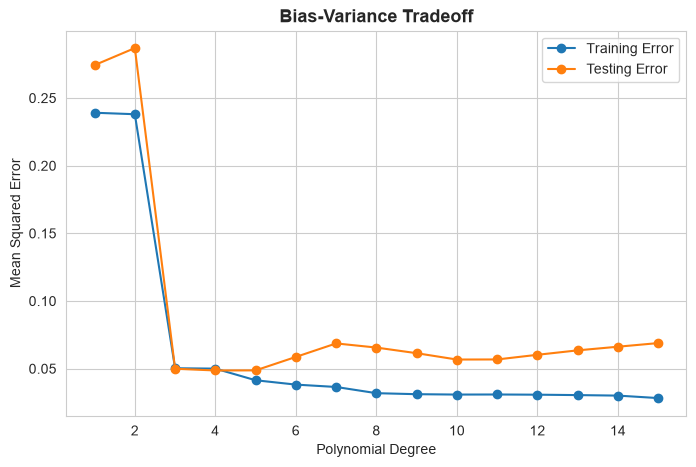

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Split the data into training and testing sets # 30% of the data held out for testing, 70% for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Store the errors
train_error = []            # will hold one MSE value per polynomial degree (on training data)
test_error = []              # will hold one MSE value per polynomial degree (on unseen test data)

# Try polynomial degrees from 1 to 15
for degree in range(1, 16):
    # Create polynomial features for this degree
    poly = PolynomialFeatures(degree=degree)
    # Transform the data (fit on train, only transform test - no leakage)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    # Create the model
    model = LinearRegression()
    # Train the model on this degree's expanded features
    model.fit(X_train_poly, y_train)
    # Make predictions on both sets
    train_predictions = model.predict(X_train_poly)
    test_predictions = model.predict(X_test_poly)
    # Calculate errors (Mean Squared Error) for both sets
    train_mse = mean_squared_error(y_train, train_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    # Save the errors for this degree so we can plot the trend afterwards
    train_error.append(train_mse)
    test_error.append(test_mse)

# Plot the results: train error keeps dropping, test error drops then rises again (bias-variance tradeoff)
plt.figure(figsize=(8,5))
plt.plot(range(1,16), train_error, marker='o', label="Training Error")
plt.plot(range(1,16), test_error, marker='o', label="Testing Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff")
plt.legend()
plt.show()


## 5. Cross Validation

Cross validation is used to evaluate how well a model performs on different subsets of the dataset. It divides the dataset into multiple parts and trains the model on different combinations of these parts to ensure the model generalizes well.
Some important aspects of cross validation include:

1.Dataset is divided into multiple parts (folds).
2.Model is trained and tested on different combinations of these folds.
3.Helps select a model that performs consistently across different data subsets.
4.Reduces the risk of the model performing well only on training data.


**Example:** With 5-fold CV, a model is trained 5 times on 80% of the data and validated on the other 20% (a different 20% each time), then the 5 scores are averaged.


In [6]:
# Cross validation demo
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression as LR   

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # 5 folds, shuffled before splitting
# for each of the 5 folds, train on the other 4, test on the held-out fold, and score it
scores = cross_val_score(LR(), X, y, cv=kf, scoring='neg_mean_squared_error')  # sklearn scoring convention: higher=better, so MSE is stored negated bec it is an error

print('Fold MSEs:', -scores)                 # flip sign back to normal positive MSE per fold
print(f'Mean CV MSE: {-scores.mean():.4f}  (+/- {scores.std():.4f})')  # average performance across folds, plus its spread (std dev) as a stability check


Fold MSEs: [0.21374449 0.35694051 0.35060859 0.23634224 0.22814022]
Mean CV MSE: 0.2772  (+/- 0.0630)


## 6. Hyperparameter Tuning

Hyperparameter tuning is the process of selecting the optimal values for a machine learning model's hyperparameters. These are typically set before the actual training process begins and control aspects of the learning process itself. Effective tuning helps the model learn better patterns, avoid overfitting or underfitting and achieve higher accuracy on unseen data.

Common tuning strategies:
- **Grid Search** CV — exhaustively tries every combination of a specified hyperparameter grid, using cross validation to score each combination.
- **Randomized Search** — samples random combinations, useful when the grid is huge.




In [7]:
from sklearn.model_selection import GridSearchCV      # exhaustively tries every hyperparameter combo you give it, using CV to score each
from sklearn.pipeline import make_pipeline             # chains preprocessing + model into a single object 

model = make_pipeline(
    PolynomialFeatures(),     # step 1: expand features expands it into x xsquare xcube
    LinearRegression()        # step 2: fit a linear model on the expanded features
)
grid = GridSearchCV(model,
    {"polynomialfeatures__degree": range(1,11)}, cv=5   # try degree = 1..10; "polynomialfeatures__degree" targets the PolynomialFeatures step's degree param inside the pipeline
)
grid.fit(X, y) # runs 5-fold CV for every degree from 1 to 10, keeps the best
print('Best degree found:', grid.best_params_["polynomialfeatures__degree"])
print(f'Best CV MSE: {-grid.best_score_:.4f}')   # best_score_ is negative MSE (sklearn convention), so negate it back


Best degree found: 4
Best CV MSE: 1.2599


## 7. Performance Metrics

### Regression metrics
- **MAE (Mean Absolute Error):** measures the average absolute difference between actual and predicted values. It treats all errors equally, regardless of their direction and provides results in the same unit as the target variable, making it easy to interpret.
- **MSE (Mean Squared Error):** calculates the average of squared differences between actual and predicted values. By squaring errors, it penalizes larger mistakes more strongly, making it sensitive to outliers.
- **RMSE (Root Mean Squared Error):** is the square root of MSE. It maintains the strong penalty for large errors while converting the result back to the original unit of the target variable, improving interpretability
- **R² Score:** represents the proportion of variance in `y` explained by the model (1 = perfect, 0 = no better than predicting the mean, negative = worse than the mean).

### Classification metrics
- **Accuracy:** It tells us the proportion of correct predictions made by the model out of all predictions.Misleading on imbalanced data.
- **Precision:** of all predicted positives, how many are actually positive — `TP / (TP + FP)`. Matters when false positives are costly.
- **Recall (Sensitivity):** of all actual positives, how many did we catch — `TP / (TP + FN)`. Matters when false negatives are costly (e.g. missing a malignant tumor).
- **F1 Score:** harmonic mean of Precision and Recall — a single balanced number.
- **ROC-AUC:** area under the ROC curve (True Positive Rate vs False Positive Rate across thresholds). 1.0 = perfect separability, 0.5 = random guessing.
- **Confusion Matrix:** table of TP, FP, TN, FN — the raw material behind every classification metric above.


# Part 2

# A. Regression: Predicting Flight Arrival Delay

**Dataset:** 2015 US domestic flights (from the uploaded `flights.csv`, ~5.8 million rows). To keep training fast and interactive, we work with a clean random sample of **40,000 completed, non-diverted flights** (`flights_sample.csv`), keeping only fields that would realistically be known once a flight has *departed* (so we're not leaking arrival-time information).

**Target:** `ARRIVAL_DELAY` (minutes; negative means early, positive means late).

**Models compared:** Linear Regression, Ridge Regression, Lasso Regression, Decision Tree Regressor, Random Forest Regressor.


In [8]:
df = pd.read_csv('flights_sample.csv')       # load the 40,000-row sample of flight records
airlines = pd.read_csv('airlines.csv')        # small lookup table: airline IATA code -> full airline name
df = df.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')  # join full airline names onto the flights, left join keeps every flight row
print(df.shape)                               # (rows, columns) after the merge
df.head()                                     # preview the first 5 rows


(40000, 19)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,DIVERTED,CANCELLED,IATA_CODE,AIRLINE_y
0,2015,8,7,5,NK,226,MYR,IAG,1111,-20.0,10.0,109.0,650,1300,-22.0,0,0,NK,Spirit Air Lines
1,2015,9,10,4,WN,549,MCO,BNA,1800,298.0,15.0,115.0,616,1855,292.0,0,0,WN,Southwest Airlines Co.
2,2015,4,8,3,DL,2373,ATL,MIA,1243,0.0,11.0,117.0,594,1440,-17.0,0,0,DL,Delta Air Lines Inc.
3,2015,11,24,2,AA,1506,BWI,DFW,1030,-1.0,15.0,219.0,1217,1309,-17.0,0,0,AA,American Airlines Inc.
4,2015,6,8,1,MQ,3437,ORD,PIA,845,0.0,17.0,58.0,130,943,-9.0,0,0,MQ,American Eagle Airlines Inc.


In [9]:
df.describe(include='all').T.head(20)        # transposed so each row is one column, showing first 20


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,40000.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,40000.0,NaN,NaN,NaN,6.557175,3.38776,1.0,4.0,7.0,9.0,12.0
DAY,40000.0,NaN,NaN,NaN,15.7756,8.784895,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,40000.0,NaN,NaN,NaN,3.92985,1.984661,1.0,2.0,4.0,6.0,7.0
AIRLINE_x,40000,14,WN,8651,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,40000.0,NaN,NaN,NaN,2157.744725,1753.919779,1.0,726.0,1675.5,3208.0,7438.0
ORIGIN_AIRPORT,40000,525,ATL,2396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,40000,537,ATL,2368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,40000.0,NaN,NaN,NaN,1330.4134,484.245294,1.0,918.0,1325.0,1731.0,2359.0
DEPARTURE_DELAY,40000.0,NaN,NaN,NaN,9.166775,36.744221,-44.0,-5.0,-2.0,7.0,1670.0


### Exploratory Data Analysis

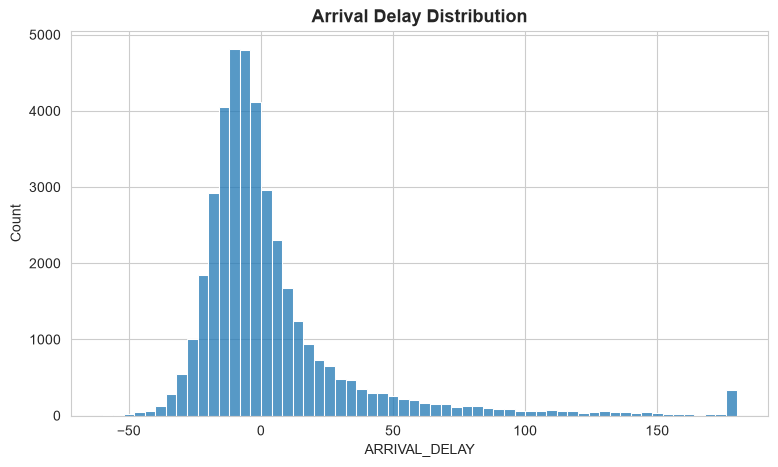

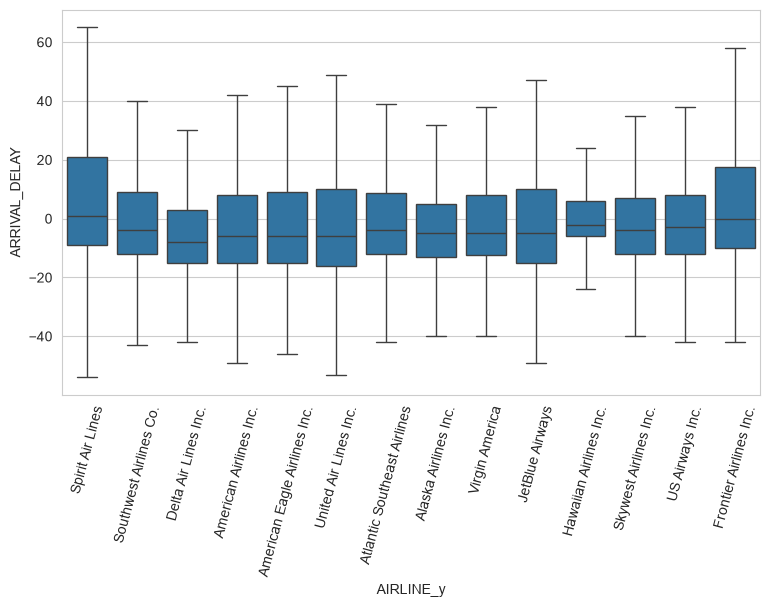

In [10]:
sns.histplot(df['ARRIVAL_DELAY'].clip(-60, 180), bins=60)
# .clip(-60, 180): cap delay values to the range -60..180 min, removes extreme outliers from skewing the chart
plt.title('Arrival Delay Distribution')
plt.show()

sns.boxplot(data=df, x='AIRLINE_y', y='ARRIVAL_DELAY', showfliers=False)
# x = one box drawn per airline
# y = each box summarizes that airline's delay spread (25th-75th percentile box, median line, whiskers)
# showfliers=False: hide individual outlier dots so the boxes stay readable
plt.xticks(rotation=75)  # tilt airline name labels 75° so long names don't overlap each other
plt.show()  # render the boxplot


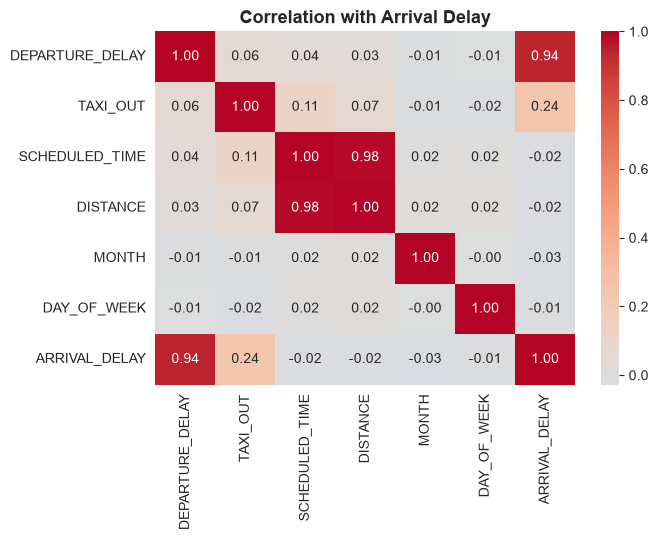

In [11]:
plt.figure(figsize=(7, 5.5))
corr_cols = ['DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'MONTH', 'DAY_OF_WEEK', 'ARRIVAL_DELAY']  # only look at correlations among these numeric columns
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)  # .corr() = pairwise correlation matrix; annot=True prints the numbers on each cell; center=0 makes 0 correlation the neutral color
plt.title('Correlation with Arrival Delay')
plt.tight_layout()
plt.show()


### Preprocessing


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer   # applies different preprocessing to different columns, then stitches results back together
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ['DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'MONTH', 'DAY_OF_WEEK']  
categorical_features = ['AIRLINE_y'] 

X = df[numeric_features + categorical_features]   # the full feature matrix (inputs)
y = df['ARRIVAL_DELAY']                            # the target we want to predict

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)  # 80% train / 20% test split

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),                       # scale numeric columns to mean 0, std 1 (helps some models converge/behave better)
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # turn airline names into 0/1 dummy columns; ignore any unseen airline at test time instead of erroring
])

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (32000, 7)  Test shape: (8000, 7)


### Training 5 Regression Models + Cross Validation + Hyperparameter Tuning

Each model is wrapped in a `Pipeline` (preprocessing + estimator). For each model we:
1. Run 5-fold cross validation with default hyperparameters to get a baseline.
2. Use `GridSearchCV` to tune key hyperparameters.
3. Evaluate the tuned model on the held-out test set.


In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso    # basic + regularized linear regressors
from sklearn.tree import DecisionTreeRegressor                      # tree-based regressor
from sklearn.ensemble import RandomForestRegressor                  # ensemble of many decision trees
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # regression scoring metrics

def build_pipe(estimator):
    # bundles any regressor together with the shared preprocessor,
    # so scaling/encoding always runs before the model sees the data
    return Pipeline([('preprocessor', preprocessor), ('model', estimator)])

# name -> (pipeline, hyperparameter grid to search over)
reg_models = {
    'Linear Regression': (build_pipe(LinearRegression()), {}),   # no hyperparameters - empty grid = just fit once with defaults
    'Ridge Regression': (build_pipe(Ridge()), {'model__alpha': [0.1, 1, 10, 50]}),        # alpha = regularization strength to try
    'Lasso Regression': (build_pipe(Lasso(max_iter=5000)), {'model__alpha': [0.01, 0.1, 1, 5]}),  # max_iter raised so it has enough iterations to converge
    'Decision Tree': (build_pipe(DecisionTreeRegressor()), {'model__max_depth': [4, 8, 12]}),      # max_depth = how deep the tree can grow
    'Random Forest': (build_pipe(RandomForestRegressor(n_jobs=-1)), {'model__n_estimators': [50, 100]}),  # n_estimators = number of trees; n_jobs=-1 uses all CPU cores
}

reg_results = []            # will collect one summary dict of scores per model
best_estimators = {}        # will store each model's best fitted pipeline, keyed by name

for name, (pipe, grid) in reg_models.items():
    # GridSearchCV works fine even with an empty grid - it just fits once with default params
    search = GridSearchCV(pipe, grid, cv=5, scoring='neg_root_mean_squared_error')  # 5-fold CV over every combo in `grid`, scored by RMSE (sklearn stores it negated)
    search.fit(X_train, y_train)               # runs the search, then refits the winning combo on the full training set

    best_model = search.best_estimator_        # the winning pipeline (preprocessing + tuned model)
    y_pred = best_model.predict(X_test)         # predictions on the held-out test set (data never used in training or tuning)

    best_estimators[name] = best_model          # save this model for later reuse (e.g. plots)
    reg_results.append({
        'Model': name,
        'CV RMSE': -search.best_score_,                                   # best cross-validated RMSE found during tuning (sign flipped back to positive)
        'Test MAE': mean_absolute_error(y_test, y_pred),                  # average absolute error, in minutes
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),         # root mean squared error, penalizes big misses more
        'Test R2': r2_score(y_test, y_pred),                               # proportion of variance explained (1 = perfect)
        'Best Params': search.best_params_,
    })

reg_results_df = pd.DataFrame(reg_results)      # turn the list of result dicts into a table, one row per model

In [14]:
(
    reg_results_df[['Model', 'CV RMSE', 'Test MAE', 'Test RMSE', 'Test R2']]
    # select just these 5 columns from the results table, in this order
    .sort_values('Test RMSE')
    # sort rows so the model with the LOWEST Test RMSE (best model) appears first
    .style.background_gradient(subset=['Test RMSE'], cmap='RdYlGn_r')
    # color the 'Test RMSE' column: cmap='RdYlGn_r' is the REVERSED red-yellow-green scale,
    # so small RMSE values (best, since lower error = better) show green, larger ones show red
    .background_gradient(subset=['Test R2'], cmap='RdYlGn')
    # color the 'Test R2' column: cmap='RdYlGn' is the NORMAL scale,
    # so high R2 values (best, since closer to 1 = more variance explained) show green, low ones show red
)

,Model,CV RMSE,Test MAE,Test RMSE,Test R2
0,Linear Regression,9.889535,7.049422,9.966649,0.922857
1,Ridge Regression,9.889527,7.049584,9.966787,0.922855
2,Lasso Regression,9.891701,7.055501,9.973294,0.922754
4,Random Forest,11.495681,7.459996,10.524190,0.913984
3,Decision Tree,12.230243,8.161675,11.307335,0.900707


In [15]:
for row in reg_results:
    # print each model's name (left-aligned, padded to 28 chars) next to the hyperparameters GridSearchCV picked as best
    print(f"{row['Model']:28s} best params: {row['Best Params']}")


Linear Regression            best params: {}
Ridge Regression             best params: {'model__alpha': 1}
Lasso Regression             best params: {'model__alpha': 0.01}
Decision Tree                best params: {'model__max_depth': 8}
Random Forest                best params: {'model__n_estimators': 100}


### Visual Comparison of Regression Models

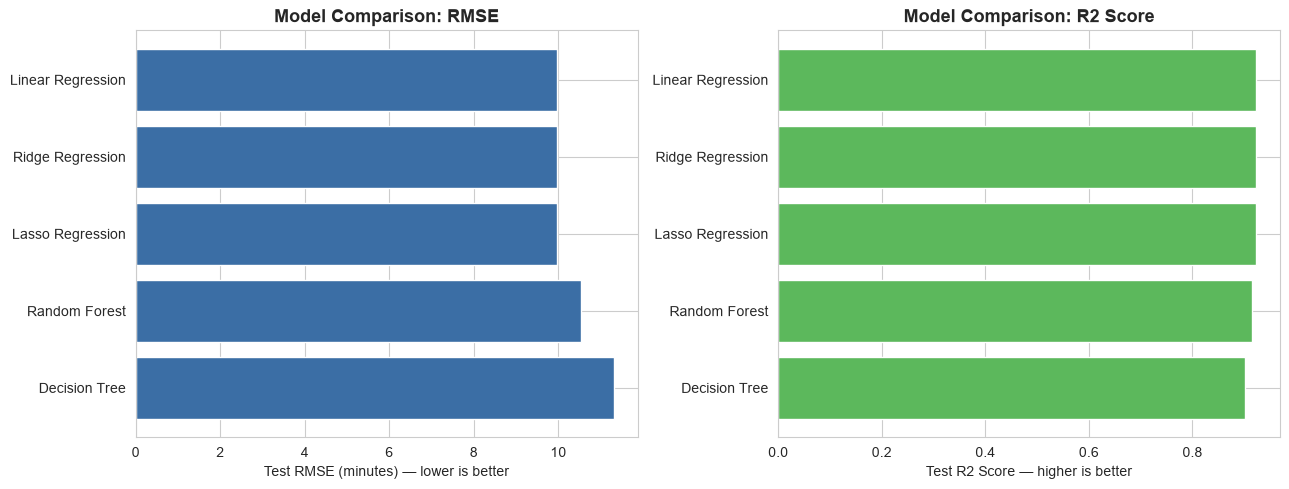

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))   # two side-by-side bar charts

order = reg_results_df.sort_values('Test RMSE')   # sort ascending -> best (lowest) RMSE first
axes[0].barh(order['Model'], order['Test RMSE'], color='#3b6ea5')   # horizontal bar chart of RMSE per model
axes[0].set_xlabel('Test RMSE (minutes) — lower is better')
axes[0].set_title('Model Comparison: RMSE')
axes[0].invert_yaxis()                            # so the best (lowest RMSE, first row) appears at the TOP of the chart

order2 = reg_results_df.sort_values('Test R2', ascending=False)   # sort descending -> best (highest) R2 first
axes[1].barh(order2['Model'], order2['Test R2'], color='#5cb85c')
axes[1].set_xlabel('Test R2 Score — higher is better')
axes[1].set_title('Model Comparison: R2 Score')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


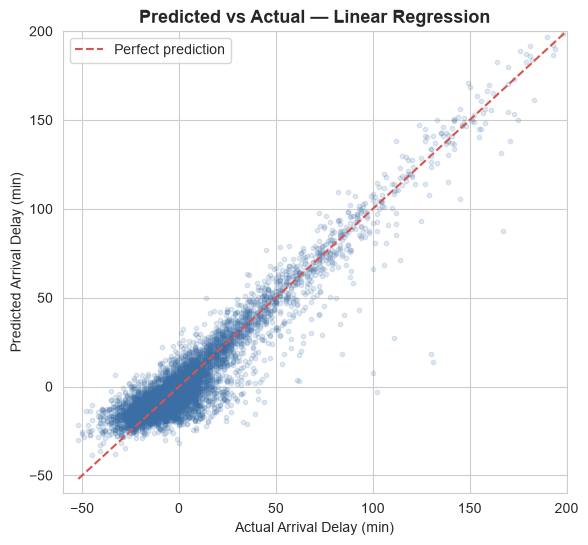

In [17]:
# Predicted vs Actual for the best model
best_reg_name = reg_results_df.sort_values('Test RMSE').iloc[0]['Model']   # name of the model with the lowest test RMSE
best_reg_model = best_estimators[best_reg_name]                             # fetch its already-fitted pipeline
y_pred_best = best_reg_model.predict(X_test)                                # get its predictions on the test set

plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred_best, alpha=0.15, s=10, color='#3b6ea5')   # low alpha (0.15) so overlapping points show density instead of one solid blob
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]   # shared axis range covering both actual and predicted values
plt.plot(lims, lims, color='#d9534f', linestyle='--', label='Perfect prediction')     # the y=x diagonal: points exactly on this line would be perfect predictions
plt.xlim(-60, 200); plt.ylim(-60, 200)          # zoom into the typical delay range (ignore rare extreme outliers)
plt.xlabel('Actual Arrival Delay (min)')
plt.ylabel('Predicted Arrival Delay (min)')
plt.title(f'Predicted vs Actual — {best_reg_name}')
plt.legend()
plt.show()


### Why does the best model perform better?

Linear Regression and Ridge Regression come out on top (lowest RMSE, highest R²), narrowly ahead of Lasso, with Decision Tree and Random Forest trailing behind despite being "more powerful" model families.

The reason: `DEPARTURE_DELAY` is almost linearly related to `ARRIVAL_DELAY` — a flight that leaves 20 minutes late tends to arrive about 20 minutes late too. This one feature explains most of the variance, so a simple linear equation already captures nearly all the signal. Ridge/Lasso barely change the result since there's little overfitting for regularization to fix with only a handful of features. The tree-based models, meanwhile, end up modeling noise instead of real structure, since there's no meaningful non-linear pattern for their extra flexibility to exploit.

**Takeaway:** more complex models aren't automatically better — when the dominant driver of the target behaves almost linearly, a simple model wins, and it's faster to train too.

# B. Classification: Breast Cancer Diagnosis

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — a classic, well-known dataset built into scikit-learn (569 samples, 30 numeric features computed from digitized images of breast masses).

**Target:** `diagnosis` — malignant (0) vs benign (1).

**Models compared:** Logistic Regression, K-Nearest Neighbors, Naive Bayes, Decision Tree, Random Forest, Support Vector Machine (6 models — more than the minimum of 5 requested).


In [18]:
from sklearn.datasets import load_breast_cancer   # built-in scikit-learn dataset

data = load_breast_cancer(as_frame=True)          # as_frame=True returns it as a pandas DataFrame instead of raw numpy arrays
cancer_df = data.frame                             # the full dataframe: 30 feature columns + a 'target' column
print(cancer_df.shape)
print('Classes:', dict(zip(data.target_names, [0, 1])))   # maps class index (0/1) to its real-world label name (malignant/benign)
cancer_df.head()


(569, 31)
Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


target
benign       357
malignant    212
Name: count, dtype: int64


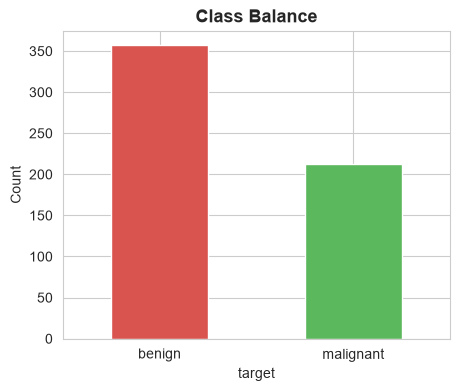

In [19]:
print(cancer_df['target'].value_counts().rename({0: 'malignant', 1: 'benign'}))   # how many samples of each class (checks for class imbalance)

plt.figure(figsize=(5, 4))
cancer_df['target'].value_counts().rename({0: 'malignant', 1: 'benign'}).plot(
    kind='bar', color=['#d9534f', '#5cb85c'])     # red bar for malignant, green for benign
plt.title('Class Balance')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()


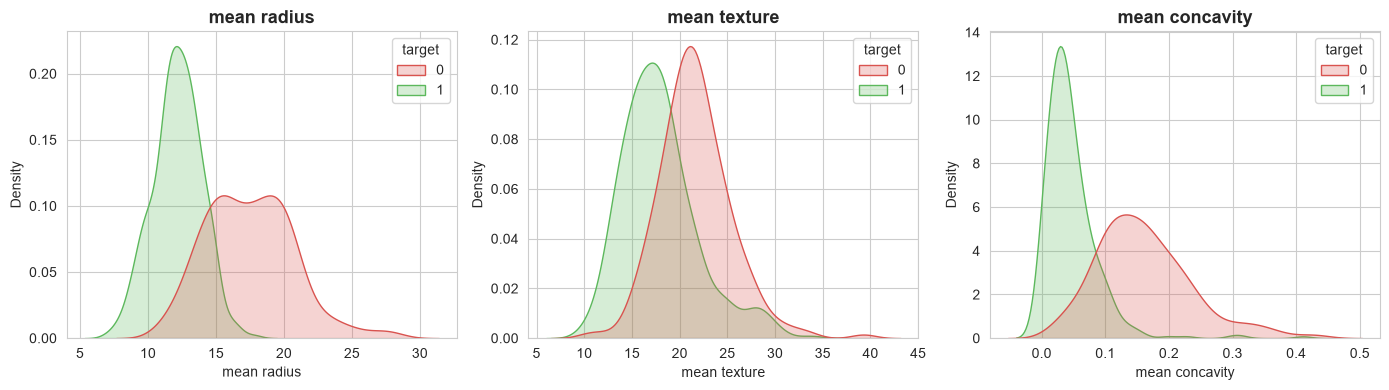

In [20]:
# A quick look at how a few features separate the classes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))   # 3 small plots side by side, one per feature
for ax, feat in zip(axes, ['mean radius', 'mean texture', 'mean concavity']):
    sns.kdeplot(data=cancer_df, x=feat, hue='target', fill=True, common_norm=False, ax=ax,
                palette={0: '#d9534f', 1: '#5cb85c'})   # overlapping density curves per class; common_norm=False so each class's curve integrates to 1 on its own (fair shape comparison even with imbalance)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


In [21]:
Xc = cancer_df.drop(columns='target')   # all 30 feature columns (everything except the label)
yc = cancer_df['target']                 # the label column (0=malignant, 1=benign)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)
# stratify=yc keeps the same malignant/benign ratio in both train and test sets (important since classes aren't perfectly balanced)
print('Train shape:', Xc_train.shape, ' Test shape:', Xc_test.shape)


Train shape: (455, 30)  Test shape: (114, 30)


### Preprocessing

All 6 classifiers are distance/coefficient based to some degree (KNN and SVM especially need scaled features), so every model is wrapped with a `StandardScaler` in a `Pipeline`.


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)

def build_clf_pipe(estimator):
    # Scale features first - KNN/SVM need this
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', estimator),
    ])

logreg_grid = {'model__C': [0.01, 0.1, 1, 10]}                  # C = inverse regularization strength (smaller = stronger)
knn_grid    = {'model__n_neighbors': [3, 5, 7, 11, 15]}          # how many neighbors vote on the class
tree_grid   = {
    'model__max_depth': [3, 5, 8, None],                          # None = unlimited depth (risk of overfitting)
    'model__min_samples_leaf': [1, 5, 10],
}
forest_grid = {
    'model__n_estimators': [100, 200],                            # number of trees
    'model__max_depth': [4, 8, None],
}
svm_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
}

clf_models = {
    'Logistic Regression': (build_clf_pipe(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)), logreg_grid),
    'KNN':                  (build_clf_pipe(KNeighborsClassifier()), knn_grid),
    'Decision Tree':        (build_clf_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE)), tree_grid),
    'Random Forest':        (build_clf_pipe(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)), forest_grid),
    'SVM':                  (build_clf_pipe(SVC(probability=True, random_state=RANDOM_STATE)), svm_grid),
}

print(list(clf_models.keys()))


['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM']


### Training 6 Classification Models + Cross Validation + Hyperparameter Tuning

Same process as the regression case: baseline 5-fold CV, then `GridSearchCV` tuning, then evaluation on the held-out test set with the full metric suite.


In [23]:
clf_results = []
best_clf_estimators = {}
roc_data = {}

for name, (pipe, grid) in clf_models.items():
    # baseline: default hyperparams, 5-fold CV, scored by F1
    baseline_cv = cross_val_score(pipe, Xc_train, yc_train, cv=5, scoring='f1', n_jobs=-1)

    if grid:
        search = GridSearchCV(pipe, grid, cv=5, scoring='f1', n_jobs=-1)
        search.fit(Xc_train, yc_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
        tuned_cv_f1 = search.best_score_
    else:
        best_model = pipe.fit(Xc_train, yc_train)
        best_params = {}
        tuned_cv_f1 = baseline_cv.mean()

    y_pred = best_model.predict(Xc_test)
    y_proba = best_model.predict_proba(Xc_test)[:, 1]   # needed for ROC/AUC

    acc = accuracy_score(yc_test, y_pred)
    prec = precision_score(yc_test, y_pred)
    rec = recall_score(yc_test, y_pred)
    f1 = f1_score(yc_test, y_pred)
    auc = roc_auc_score(yc_test, y_proba)

    best_clf_estimators[name] = best_model
    fpr, tpr, _ = roc_curve(yc_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

    clf_results.append({
        'Model': name,
        'Baseline CV F1': baseline_cv.mean(),
        'Tuned CV F1': tuned_cv_f1,
        'Best Params': best_params,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': auc,
    })
    print(f'{name:20s} -> Acc={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f}')

clf_results_df = pd.DataFrame(clf_results)

Logistic Regression  -> Acc=0.974, F1=0.979, AUC=0.996
KNN                  -> Acc=0.974, F1=0.980, AUC=0.988
Decision Tree        -> Acc=0.921, F1=0.937, AUC=0.937
Random Forest        -> Acc=0.956, F1=0.966, AUC=0.994
SVM                  -> Acc=0.982, F1=0.986, AUC=0.994


In [24]:
clf_results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]\
    .sort_values('F1 Score', ascending=False)\
    .style.background_gradient(
        subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'], cmap='RdYlGn')
# sort so the best F1 score is on top, then color every metric column green=good / red=bad for a quick visual scan


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,SVM,0.982456,0.986111,0.986111,0.986111,0.993717
1,KNN,0.973684,0.960000,1.000000,0.979592,0.988426
0,Logistic Regression,0.973684,0.972603,0.986111,0.979310,0.995701
3,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993717
2,Decision Tree,0.921053,0.943662,0.930556,0.937063,0.936839


In [25]:
for row in clf_results:
    print(f"{row['Model']:20s} best params: {row['Best Params']}")


Logistic Regression  best params: {'model__C': 0.1}
KNN                  best params: {'model__n_neighbors': 7}
Decision Tree        best params: {'model__max_depth': 5, 'model__min_samples_leaf': 5}
Random Forest        best params: {'model__max_depth': 8, 'model__n_estimators': 200}
SVM                  best params: {'model__C': 0.1, 'model__kernel': 'linear'}


### Visual Comparison of Classification Models

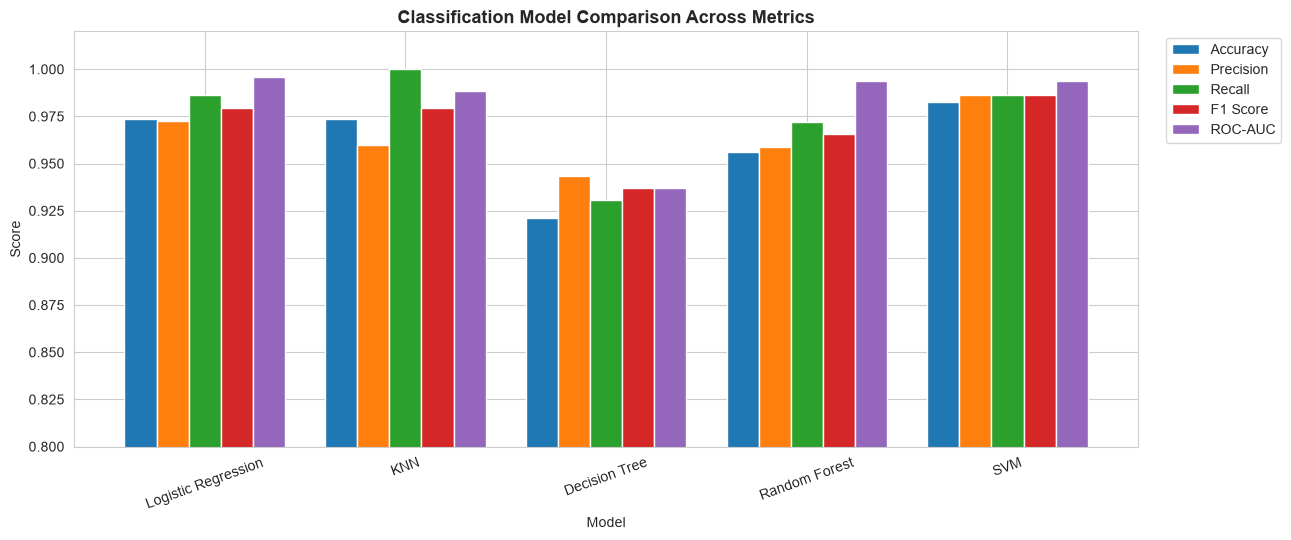

In [26]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
plot_df = clf_results_df.set_index('Model')[metrics_to_plot]   # re-index by model name so each bar-group is labeled by model

plot_df.plot(kind='bar', figsize=(13, 5.5), width=0.8)   # grouped bar chart: one group per model, one bar per metric
plt.title('Classification Model Comparison Across Metrics')
plt.ylabel('Score')
plt.ylim(0.8, 1.02)          # zoom in since all these models score fairly high (>0.8) - makes differences easier to see
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')   # push the legend outside the plot area so it doesn't cover bars
plt.tight_layout()
plt.show()


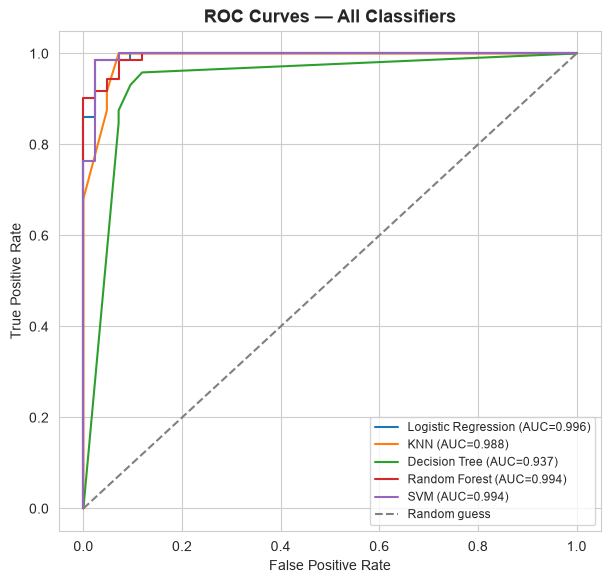

In [27]:
# ROC Curves for all models
plt.figure(figsize=(7, 6.5))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')   # one curve per model; a curve that hugs the top-left corner = better model
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')   # diagonal = performance of a coin-flip classifier, baseline reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Classifiers')
plt.legend(fontsize=8.5)
plt.show()


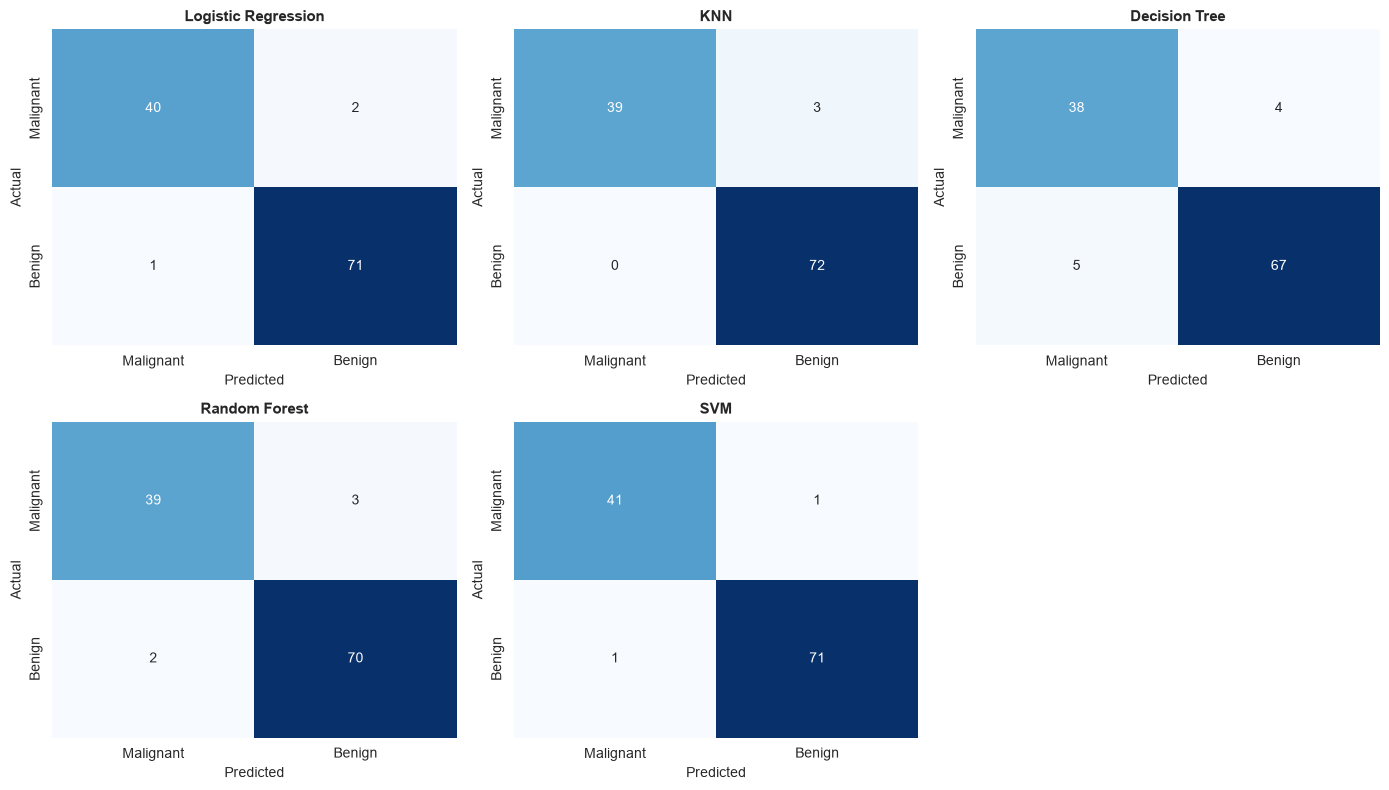

In [28]:
# Confusion matrices for all 5 models
fig, axes = plt.subplots(2, 3, figsize=(14, 8))   # 2x3 grid = 6 slots for 5 models; last slot stays empty
for ax, (name, model) in zip(axes.ravel(), best_clf_estimators.items()):   # .ravel() flattens the 2x3 grid into a simple list to zip over
    cm = confusion_matrix(yc_test, model.predict(Xc_test))   # 2x2 table: rows=actual class, cols=predicted class, counts in each cell
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])   # fmt='d' = show counts as integers, not decimals
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    
for ax in axes.ravel()[len(best_clf_estimators):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### Why does the best model perform better?

Logistic Regression and SVM tend to lead on this dataset because the 30 features separate malignant vs benign tumors in a way that's close to linearly separable after scaling — logistic regression finds a clean decision boundary, and SVM's margin-maximizing objective (plus RBF kernel, when tuned) can pick up small non-linear adjustments a plain linear model misses.

KNN performs well once features are scaled, but is more sensitive to `n_neighbors` and to noisy features diluting distance calculations. Decision Tree alone tends to overfit unless depth is constrained, which shows up as weaker test recall/precision. Random Forest usually closes most of that gap by averaging many trees to reduce variance, while also handling any non-linear interactions the linear models can't.

**Takeaway:** this dataset has strong, mostly linear class separation, so linear/margin-based models (Logistic Regression, SVM) tend to lead, with Random Forest as a solid non-linear alternative.